# Downscale Sentinel-3 LST Products

In this example, a downscaler is trained with previously downloaded Sentinel-3 data
which is then used to downscale LST. The results are subsequently plotted.


## Import Packages


In [ ]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from s3lst_ds.downscaling.downscale.downscale import downscale
from s3lst_ds.downscaling.downscale.downscale_config import DownscaleConfig

## Downscale Products


### Configure

With the configuration below, one intends to:

- use the Sentine-3 products found at directory `./data`;
- masking out the data outside of the Lisbon metropolitan area (represented by a
  [WKT](https://wktmap.com/) string);
- using 5 processors in the wrangling of the data (reprojecting, combining, masking and
  transforming);
- using a multi-timestamp downscaling Linear Regression model;
- with `"FVC"`, `"NDWI"`, `"season"` as predictors;
- standardising the numerical predictors (`"FVC"`, `"NDWI"`);
- dummy-encoding the categorical predictors (`"season"`);
- considering timestamp-specific standardization of the spatio-temporal variables
  (`"FVC"`, `"NDWI"` and `"LST"`);
- using 5 processors in prediction and scoring;
- training with all timestamps and predicting (downscaling) for timestamps
  `"20210716T104226"` and `"20210717T111751"`;
- scoring the model;
- with metrics $R^2$ (`r2`), Root Mean Square Error (`rmse`), Mean Absolute Error
  (`mae`) and Mean Bias Error (`mbe`);
- considering residual correction of the fine predictions;
- outputting gridded downscaled products;
- not returning the data wrangler and trained downscaler;
- logging the whole process into the terminal.


In [2]:
downscale_config = DownscaleConfig(
    data_wrangler_path_sentinel3=Path("./data"),
    data_wrangler_aoi="POLYGON ((-9.53 38.57, -9.05 38.57, -9.05 38.92, -9.53 38.92, -9.53 38.57))",
    data_wrangler_max_workers=5,
    downscaler_architecture="multi",
    downscaler_base_model=LinearRegression(),
    downscaler_X=[
        "FVC",
        "NDWI",
        "season",
    ],
    downscaler_masks=["aoi"],
    downscaler_scale="standardize",
    downscaler_encode="dummy",
    downscaler_transform="standardize",
    downscaler_max_workers=5,
    timestamps_infer=["20210716T104226", "20210717T111751"],
    timestamps_fit=None,
    score=True,
    scorers=["r2", "rmse", "rmse_delta", "mae", "mbe"],
    correct=True,
    gridded=True,
    out_data_wrangler=False,
    out_downscaler=False,
    log_mode="console",
)

### Downscale

To train the downscaler and downscale with it, the function below is used.


In [3]:
data_lst_ds = downscale(downscale_config)["y_fine_pred"]  # type: ignore


INFO     Downscaling Sentinel-3 LST products                                            

INFO     The data will now be wrangled.                                                 
INFO     Getting a SingleDataWrangler instance for each timestamp and performing        
         wrangling of the respective data...                                            
         100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11  [ 0:00:00 < 0:00:00 , 51 timestamp/s ]:--:-- , ? timestamp/s ]
INFO     Data wrangled.                                                                 

INFO     The downscaler will now be trained.                                            
⠋        Training downscaler with the coarse data...
INFO     Downscaler trained.                                                            

INFO     LST will now be downscaled.                                                    
INFO     Predicting raw target...                                                       
         100% ━━━━━━━━━━━━━━━

## Plot Downscaled LST Products


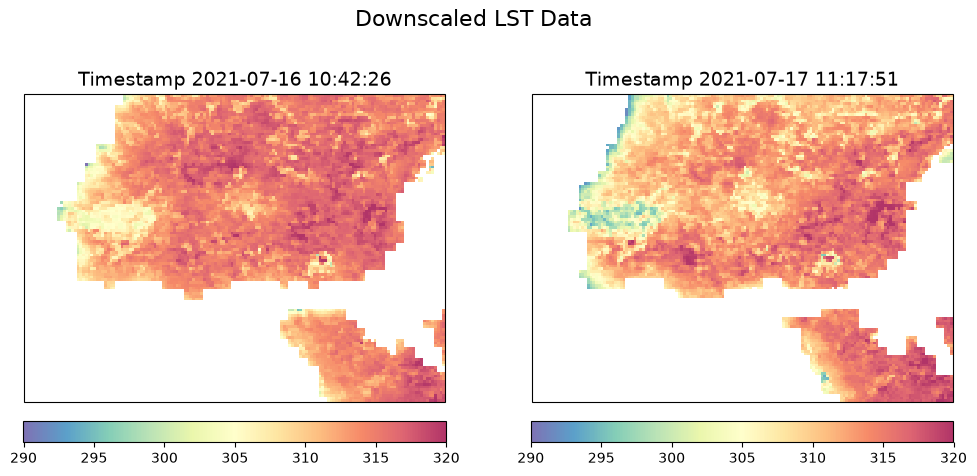

In [4]:
# Define the coordinate reference system to use in the plot
crs = ccrs.PlateCarree()


# Initialise figure and axes using a given CRS
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(data_lst_ds),
    figsize=(12, 5),
    subplot_kw={"projection": crs},
)

fig.suptitle(
    "Downscaled LST Data",
    fontsize=16,
    y=1.05,
)

for ax, timestamp in zip(axs, data_lst_ds):
    img = data_lst_ds[timestamp].plot(  # type: ignore
        ax=ax,
        cmap="Spectral_r",
        alpha=0.8,
        cbar_kwargs={
            "orientation": "horizontal",
            "pad": 0.05,
            "label": None,
        },
        vmin=290,
        vmax=320,
        # "neither" to make the colorbar to exactly end at vmin and vmax
        extend="neither",
        # Project the data to the given CRS if it is not already in that CRS
        transform=crs,
    )  # type: ignore

    ax.set_title(f"Timestamp {timestamp.strftime('%Y-%m-%d %H:%M:%S')}", fontsize=14)  # type: ignore

plt.show()